In [1]:
import numpy as np
# import seaborn as sns
import pandas as pd
import os.path

import matplotlib.pyplot as plt

import tifffile 
import czifile

from skimage import transform
from scipy import ndimage

import random 
import math
from scipy.ndimage import distance_transform_cdt

In [24]:

major_ch = 1
ctr_or_y = 'y'
ctrl_y_str = ctr_or_y+'_ch'+str(major_ch)+'_major'
seg_folder_str = 'code_org_20250820_seg'

if(ctr_or_y=='ctrl'):
    image_folder = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/Control'
if(ctr_or_y=='y'):
    image_folder = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/Ycomp'

cell_mask_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/'+ctrl_y_str+'/'+seg_folder_str+'/mask'

front_mask_dir = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/frontmasks'

In [51]:
def int_stat_4chczi_cellmask_frontmask(image_folder, cell_mask_folder, front_mask_dir):
        
    filenames = [
        x for x in os.listdir(image_folder)
        if os.path.isfile(os.path.join(image_folder, x)) and ('.czi' in x)
    ]

    all_pixel_data = []   # collect per-image arrays here

    for filenameID in range(0, len(filenames)):

        filename = filenames[filenameID]
        print("Processing:", filename)

        # -----------------------------
        # 1. Load multi-channel image
        # -----------------------------
        train_img = czifile.imread(os.path.join(image_folder, filename))

        # Shape of CZI is often (1,1,Channels,Y,X) or (Channels,Y,X)
        train_img = np.squeeze(train_img)   # remove singleton dims

        if train_img.ndim == 2:
            raise ValueError("Image has only 1 channel, expected 4 channels.")

        # Expected shape → (C, H, W)
        if train_img.shape[0] < train_img.shape[-1]:
            num_channels = train_img.shape[0]
            H, W = train_img.shape[1], train_img.shape[2]
        else:
            # fallback if C is last (unlikely for czi)
            train_img = np.moveaxis(train_img, -1, 0)
            num_channels = train_img.shape[0]
            H, W = train_img.shape[1], train_img.shape[2]

        # ---------------------------------
        # 2. Load masks (same spatial size)
        # ---------------------------------
        cell_mask = tifffile.imread(
            os.path.join(cell_mask_folder, "cell_mask_" + filename + ".tif")
        ).squeeze().astype(float)

        front_mask = tifffile.imread(
            os.path.join(front_mask_dir, 'frontmask_' + filename[:-4] + '.tif')
        ).squeeze().astype(float)/255
        front_mask = front_mask*cell_mask

        # ---------------------------------
        # 3. Flatten everything per-pixel
        # ---------------------------------
        # Flatten channels → each becomes (H*W,)
        ch_flat = [train_img[ch].reshape(-1) for ch in range(num_channels)]

        # flatten masks
        cell_flat  = cell_mask.reshape(-1)
        front_flat = front_mask.reshape(-1)

        # Stack columns: [ch1, ch2, ch3, ch4, cell_flag, front_flag]
        pixel_matrix = np.column_stack(ch_flat + [cell_flat, front_flat])

        # Append
        all_pixel_data.append(pixel_matrix)

    # -------------------------------------
    # 4. Concatenate all images’ pixel rows
    # -------------------------------------
    all_pixel_data = np.concatenate(all_pixel_data, axis=0)

    print("Final pixel matrix shape:", all_pixel_data.shape)
    # → (N_total_pixels, 4 + 2)

    return all_pixel_data

In [26]:
y_all_pixel_data = int_stat_4chczi_cellmask_frontmask(image_folder, cell_mask_folder, front_mask_dir)

Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-01.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-02.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-03.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-04.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-05.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-06.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-07.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-08.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-09.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-10.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-11.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-12.czi
Proc

In [27]:

major_ch = 1
ctr_or_y = 'ctrl'
ctrl_y_str = ctr_or_y+'_ch'+str(major_ch)+'_major'
seg_folder_str = 'code_org_20250820_seg'

if(ctr_or_y=='ctrl'):
    image_folder = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/Control'
if(ctr_or_y=='y'):
    image_folder = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/Ycomp'

cell_mask_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/'+ctrl_y_str+'/'+seg_folder_str+'/mask'

front_mask_dir = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/frontmasks'

In [28]:
ctrl_all_pixel_data = int_stat_4chczi_cellmask_frontmask(image_folder, cell_mask_folder, front_mask_dir)

Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-01.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-02.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-03.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-04.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-05.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-06.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-07.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-08.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-09.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-10.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_control-11.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m

In [30]:
ctrl_all_pixel_data.shape

(52428800, 6)

In [31]:
y_all_pixel_data.shape

(42991616, 6)

In [36]:
all_pixel_data = np.concatenate(
    [ctrl_all_pixel_data, y_all_pixel_data],
    axis=0
)


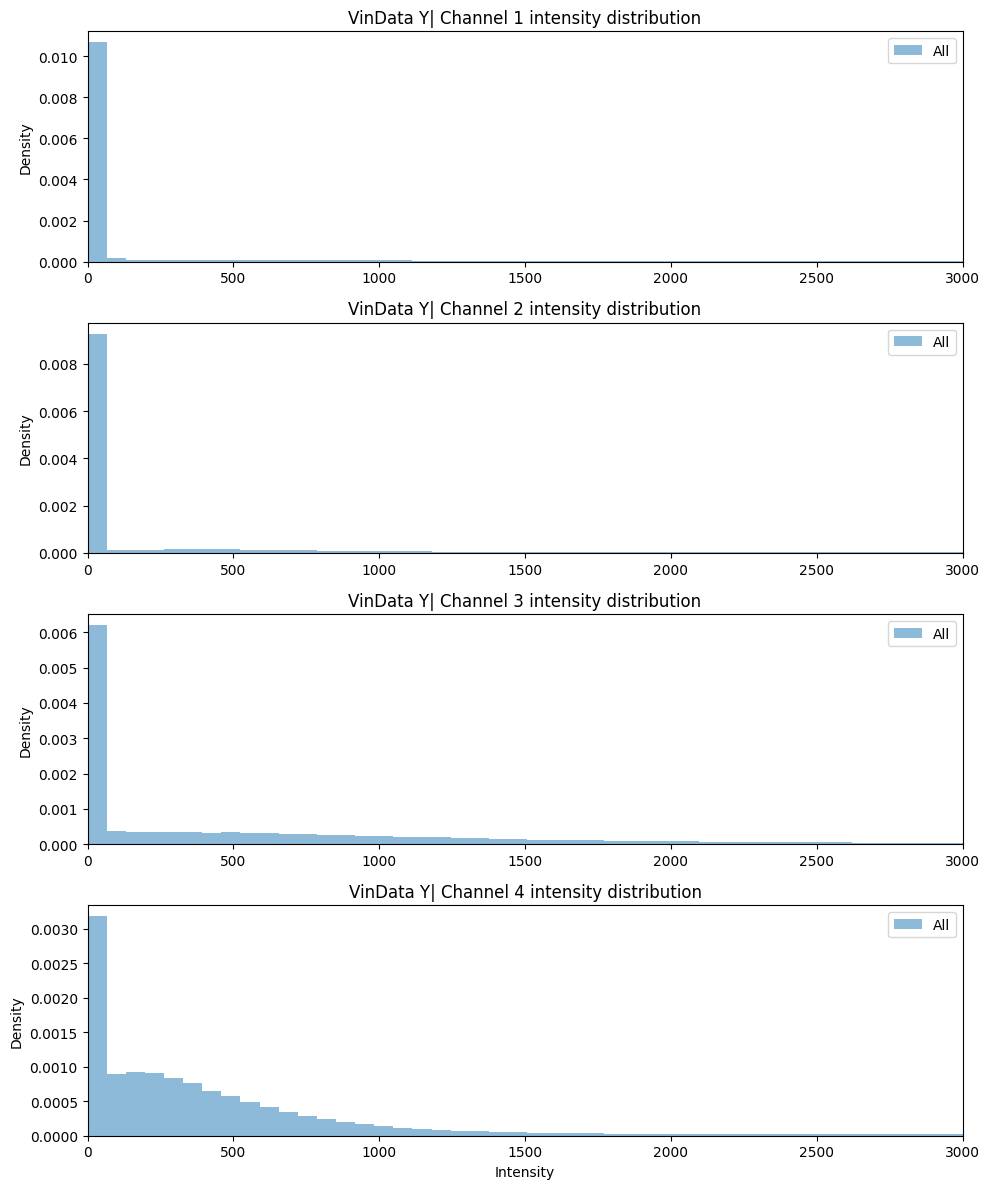

In [10]:
import matplotlib.pyplot as plt
import numpy as np

num_channels = 4

cell_idx  = all_pixel_data[:, 4] > 0
front_idx = all_pixel_data[:, 5] > 0

fig, axes = plt.subplots(num_channels, 1, figsize=(10, 3*num_channels))

if num_channels == 1:
    axes = [axes]

for ch in range(num_channels):
    ax = axes[ch]

    ch_all   = all_pixel_data[:, ch][::4]
    # ch_cell  = all_pixel_data[cell_idx, ch][::4]
    # ch_front = all_pixel_data[front_idx, ch][::10]

    bins = 1000  # adjust if needed

    ax.hist(ch_all, bins=bins, density=True, alpha=0.5, label="All")
    # ax.hist(ch_cell, bins=bins, density=True, alpha=0.5, label="Cell")
    # ax.hist(ch_front, bins=bins, density=True, alpha=0.5, label="Front")

    ax.set_title(f"VinData Y| Channel {ch+1} intensity distribution")
    ax.set_ylabel("Density")
    ax.legend()
    ax.set_xlim([0,3000])

axes[-1].set_xlabel("Intensity")

plt.tight_layout()
plt.show()


In [38]:
all_pixel_data.shape

(95420416, 6)

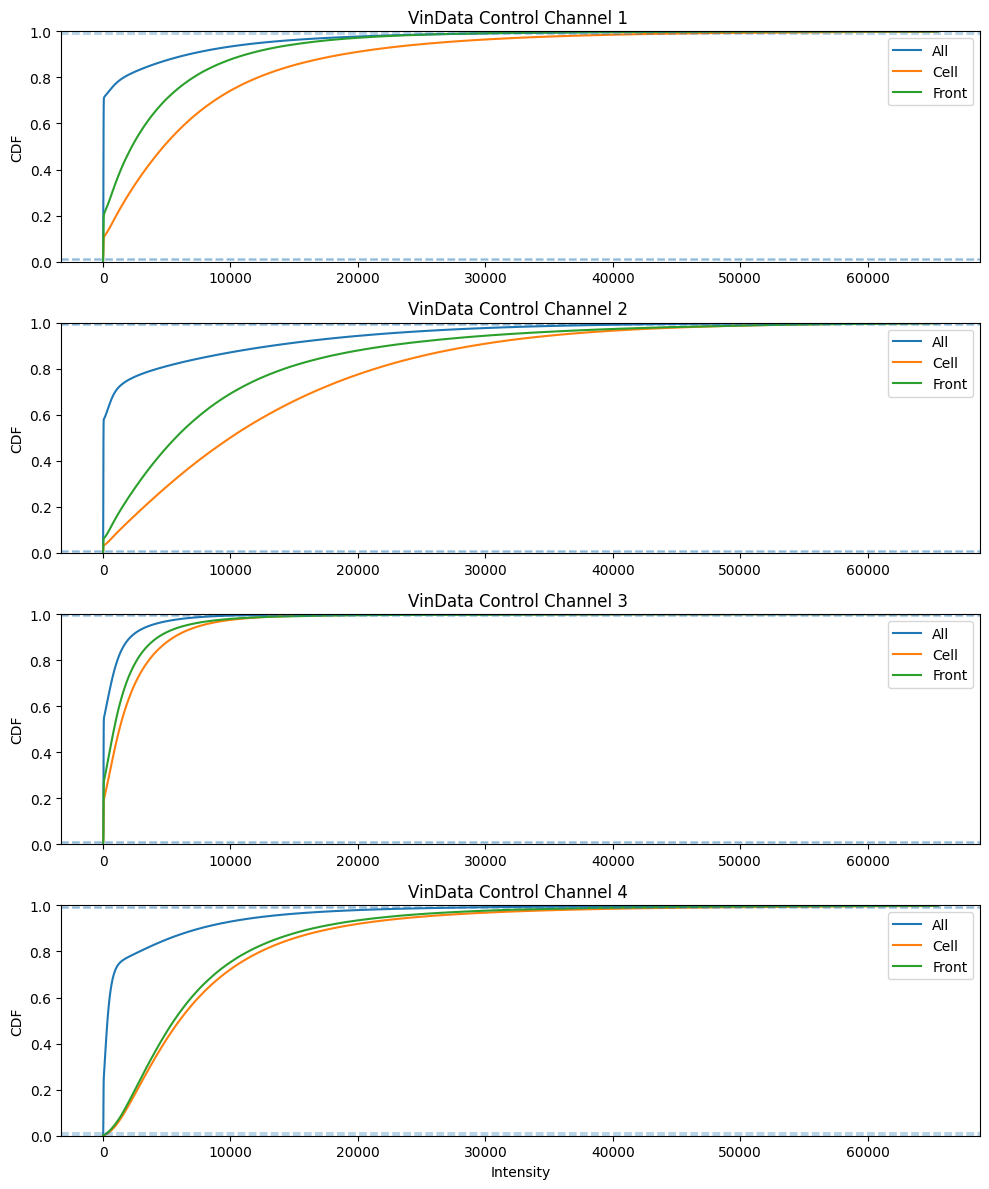

In [39]:
import matplotlib.pyplot as plt
import numpy as np

num_channels = 4

cell_idx  = all_pixel_data[:, 4] > 0
front_idx = all_pixel_data[:, 5] > 0

def ecdf(x):
    """Empirical CDF."""
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

fig, axes = plt.subplots(num_channels, 1, figsize=(10, 3*num_channels), sharex=False)

if num_channels == 1:
    axes = [axes]

for ch in range(num_channels):
    ax = axes[ch]

    ch_all   = all_pixel_data[:, ch][::10]
    ch_cell  = all_pixel_data[cell_idx, ch][::10]
    ch_front = all_pixel_data[front_idx, ch][::10]

    for data, label in [(ch_all, "All"), (ch_cell, "Cell"), (ch_front, "Front")]:
        xs, ys = ecdf(data)
        ax.plot(xs, ys, label=label)

    # Optional: show percentile guide lines
    for p in [0.5, 1, 99, 99.5]:
        ax.axhline(p/100.0, linestyle="--", alpha=0.3)

    ax.set_title(f"VinData Control Channel {ch+1} ")
    ax.set_ylabel("CDF")
    ax.set_ylim(0, 1)
    ax.legend()

axes[-1].set_xlabel("Intensity")

plt.tight_layout()
plt.show()


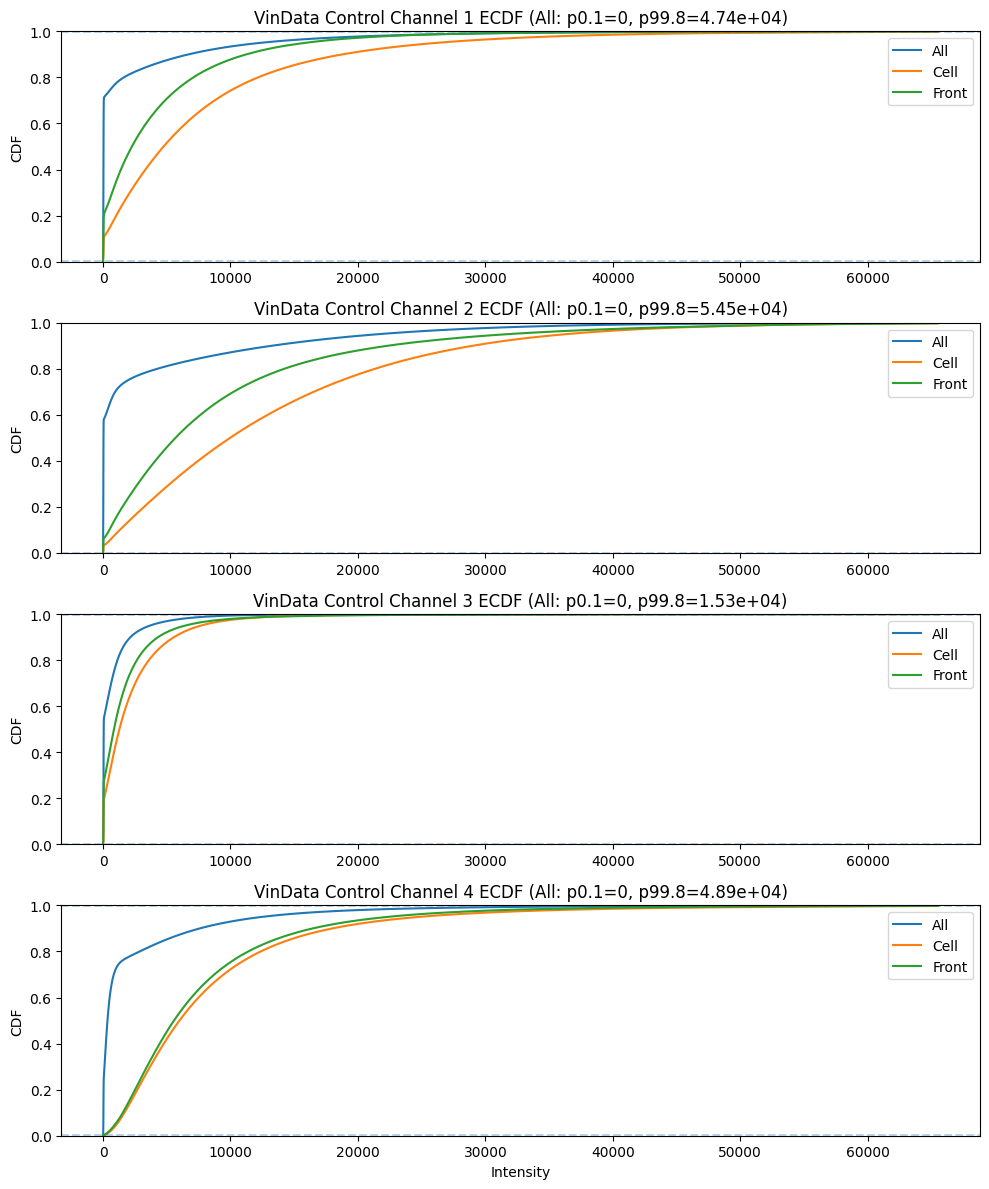

In [40]:
import matplotlib.pyplot as plt
import numpy as np

num_channels = 4

cell_idx  = all_pixel_data[:, 4] > 0
front_idx = all_pixel_data[:, 5] > 0

def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

fig, axes = plt.subplots(num_channels, 1, figsize=(10, 3*num_channels), sharex=False)

if num_channels == 1:
    axes = [axes]

for ch in range(num_channels):
    ax = axes[ch]

    ch_all   = all_pixel_data[:, ch][::10]
    ch_cell  = all_pixel_data[cell_idx, ch][::10]
    ch_front = all_pixel_data[front_idx, ch][::10]

    # ---- percentiles from ch_all ----
    p_lo = np.percentile(ch_all, 0.1)
    p_hi = np.percentile(ch_all, 99.8)

    for data, label in [(ch_all, "All"), (ch_cell, "Cell"), (ch_front, "Front")]:
        xs, ys = ecdf(data)
        ax.plot(xs, ys, label=label)

    # Optional guide lines
    for p in [0.1, 99.8]:
        ax.axhline(p / 100.0, linestyle="--", alpha=0.3)

    ax.set_title(
        f"VinData Control Channel {ch+1} ECDF "
        f"(All: p0.1={p_lo:.3g}, p99.8={p_hi:.3g})"
    )
    ax.set_ylabel("CDF")
    ax.set_ylim(0, 1)
    ax.legend()

axes[-1].set_xlabel("Intensity")

plt.tight_layout()
plt.show()


47688.0
42980.0


(0.0, 1000.0)

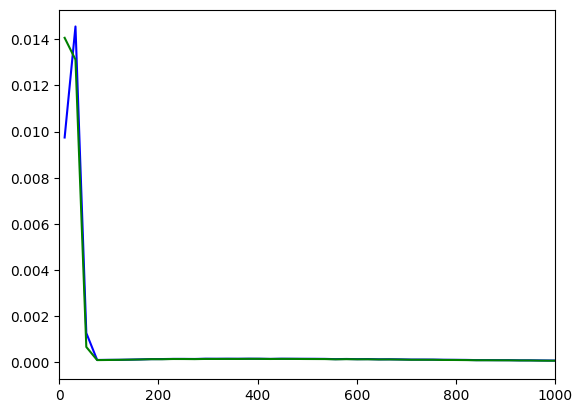

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def hist_pdf_curve(x, bins=200, range=None):
    hist, bin_edges = np.histogram(x, bins=bins, range=range, density=True)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    return bin_centers, hist

# Example usage inside your loop
bins = 3000

x_all = ctrl_all_pixel_data[:, 1][::10]
xc, yc = hist_pdf_curve(x_all, bins=bins)
print(np.percentile(ctrl_all_pixel_data[:, 1],99.5))
plt.plot(xc, yc, color='blue')
# plt.xlim([0,6000])

x_all = y_all_pixel_data[:, 1][::10]
xc, yc = hist_pdf_curve(x_all, bins=bins)
print(np.percentile(y_all_pixel_data[:, 1],99.5))
plt.plot(xc, yc, color='green')
plt.xlim([0,1000])

/tmp/ipykernel_531158/4173525782.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True, showfliers=False)
/tmp/ipykernel_531158/4173525782.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True, showfliers=False)
/tmp/ipykernel_531158/4173525782.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True, showfliers=False)
/tmp/ipykernel_531158/4173525782.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support fo

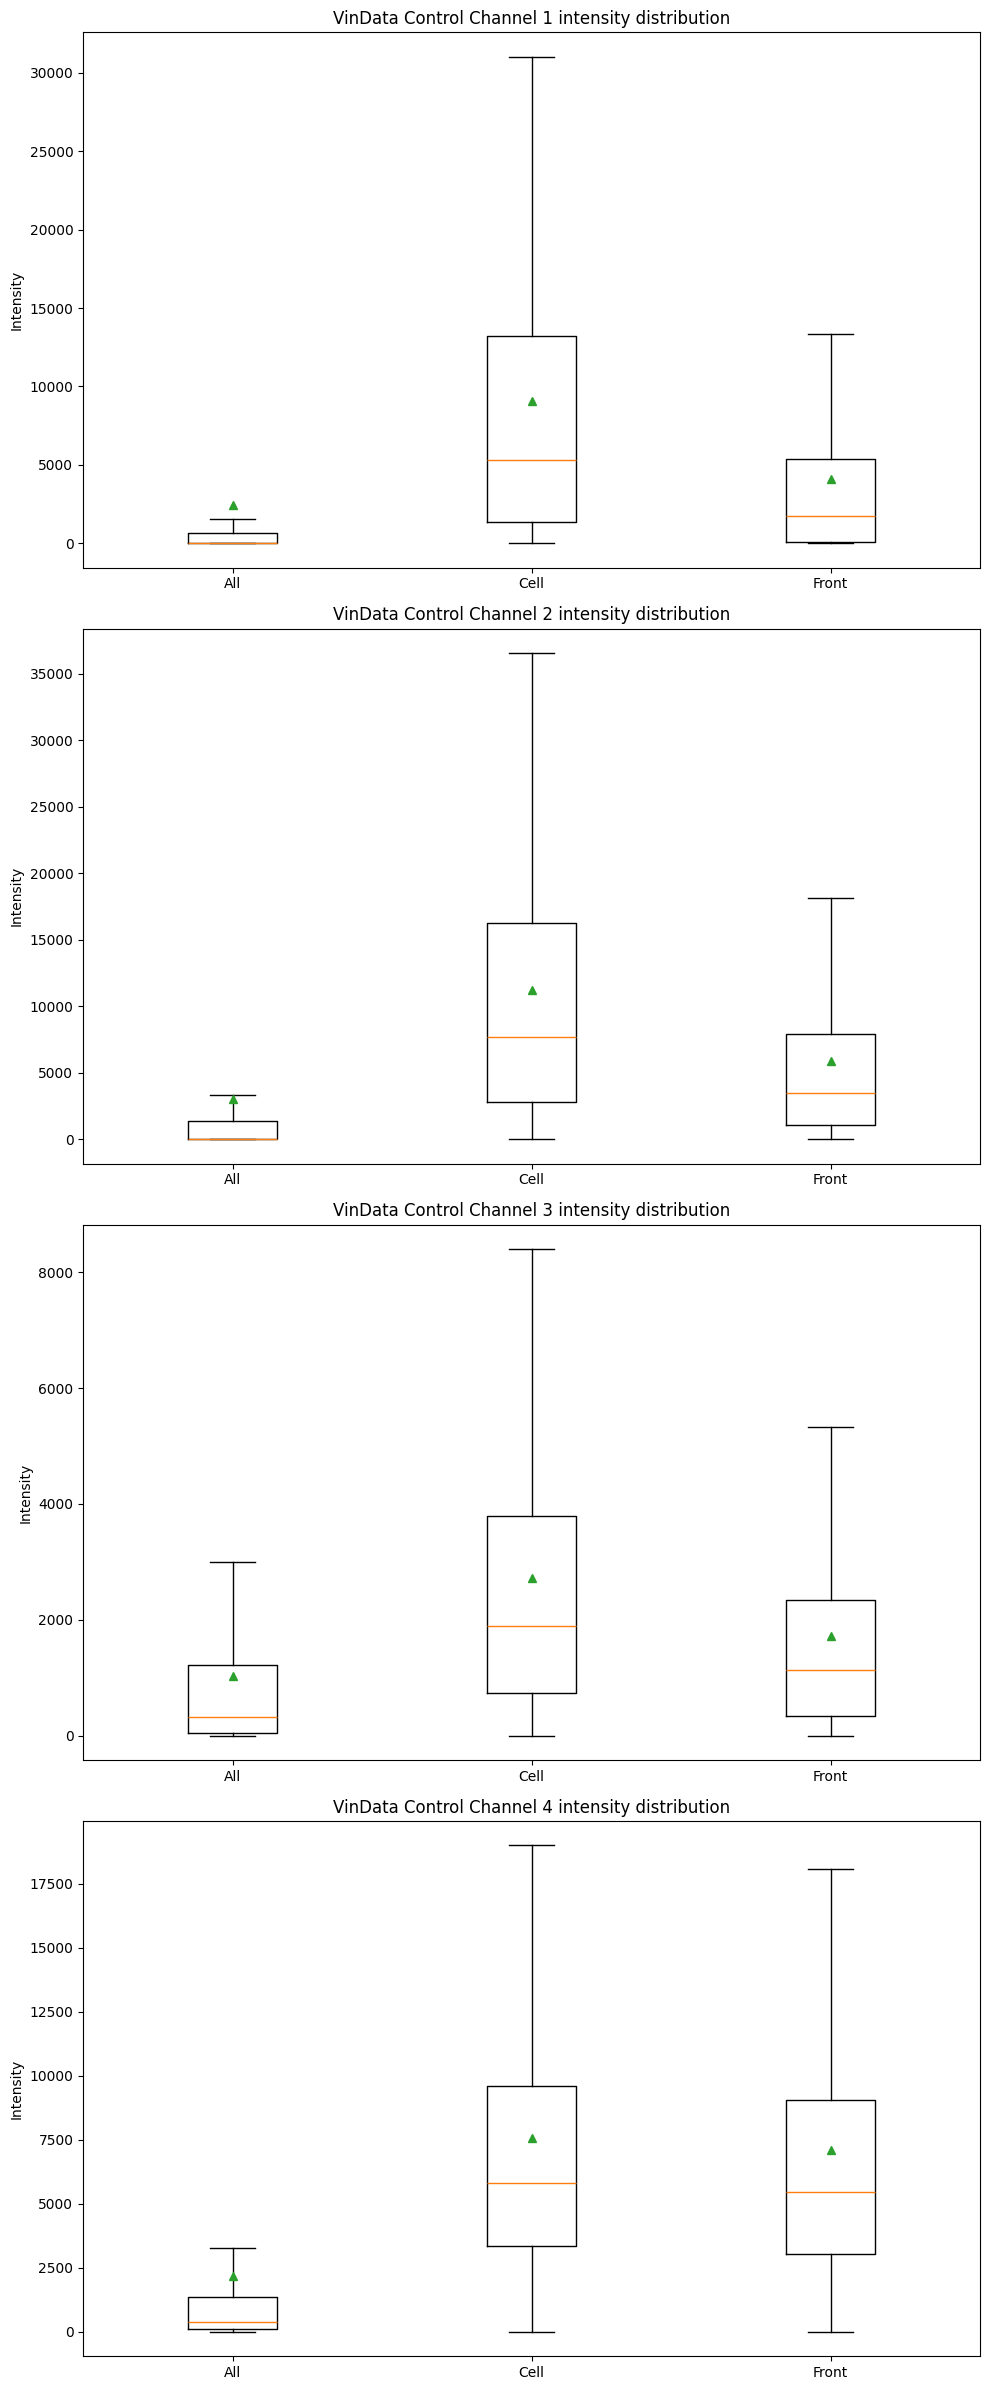

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

num_channels = 4

cell_idx  = all_pixel_data[:, 4] > 0
front_idx = all_pixel_data[:, 5] > 0

fig, axes = plt.subplots(num_channels, 1, figsize=(10, 3*2*num_channels))

if num_channels == 1:
    axes = [axes]  # ensure iterable

for ch in range(num_channels):

    ch_all   = all_pixel_data[:, ch]
    ch_cell  = all_pixel_data[cell_idx, ch]
    ch_front = all_pixel_data[front_idx, ch]

    data = [ch_all[::10], ch_cell[::10], ch_front[::10]]
    labels = ["All", "Cell", "Front"]

    ax = axes[ch]

    
    ax.boxplot(data, labels=labels, showmeans=True, showfliers=False)

    # # Optional: adjust violin colors
    # for pc in parts['bodies']:
    #     pc.set_alpha(0.6)

    ax.set_title(f"VinData Control Channel {ch+1} intensity distribution")
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(labels)
    ax.set_ylabel("Intensity")

plt.tight_layout()
plt.show()


In [49]:

major_ch = 1
ctr_or_y = 'y'
ctrl_y_str = ctr_or_y+'_ch'+str(major_ch)+'_major'
seg_folder_str = 'code_org_20250902_seg'

if(ctr_or_y=='ctrl'):
    image_folder = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/Control'
if(ctr_or_y=='y'):
    image_folder = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/Y-comp'

cell_mask_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/0311pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/'+ctrl_y_str+'/'+seg_folder_str+'/mask'

front_mask_dir = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/frontmasks'

In [52]:
pPax_y_all_pixel_data = int_stat_4chczi_cellmask_frontmask(image_folder, cell_mask_folder, front_mask_dir)

Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_ycomp-01.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_ycomp-02.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_ycomp-03.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_ycomp-04.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_ycomp-05.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_ycomp-06.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_ycomp-07.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_ycomp-08.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_ycomp-09.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_ycomp-10.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_ycomp-11.czi
Final pixel matrix shape: (11534336, 6)


In [53]:

major_ch = 1
ctr_or_y = 'ctrl'
ctrl_y_str = ctr_or_y+'_ch'+str(major_ch)+'_major'
seg_folder_str = 'code_org_20250902_seg'

if(ctr_or_y=='ctrl'):
    image_folder = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/Control'
if(ctr_or_y=='y'):
    image_folder = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/Y-comp'

cell_mask_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/0311pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/'+ctrl_y_str+'/'+seg_folder_str+'/mask'

front_mask_dir = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/frontmasks'

In [55]:
pPax_ctrl_all_pixel_data = int_stat_4chczi_cellmask_frontmask(image_folder, cell_mask_folder, front_mask_dir)

Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_control-01.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_control-02.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_control-03.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_control-04.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_control-05.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_control-06.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_control-07.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_control-08.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_control-09.czi
Processing: eGFP-Zyxin 488_Phalloidin405_pPaxy118(rb) 647_Pax(m)568_control-10.czi
Final pixel matrix shape: (10485760, 6)


27807.0
17475.0


(0.0, 1000.0)

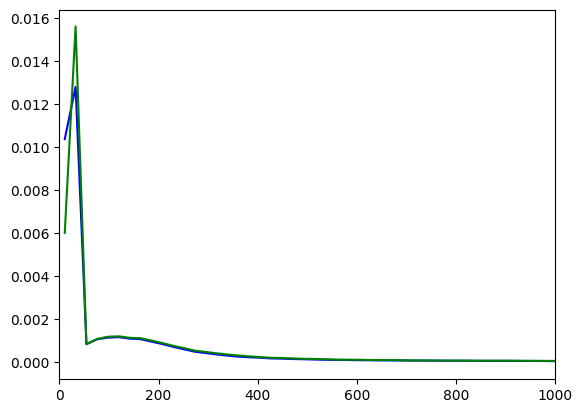

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def hist_pdf_curve(x, bins=200, range=None):
    hist, bin_edges = np.histogram(x, bins=bins, range=range, density=True)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    return bin_centers, hist

# Example usage inside your loop
bins = 3000

x_all = pPax_ctrl_all_pixel_data[:, 1][::10]
xc, yc = hist_pdf_curve(x_all, bins=bins)
print(np.percentile(pPax_ctrl_all_pixel_data[:, 1],99.5))
plt.plot(xc, yc, color='blue')
# plt.xlim([0,6000])

x_all = pPax_y_all_pixel_data[:, 1][::10]
xc, yc = hist_pdf_curve(x_all, bins=bins)
print(np.percentile(pPax_y_all_pixel_data[:, 1],99.5))
plt.plot(xc, yc, color='green')
plt.xlim([0,1000])

In [57]:
pPax_all_pixel_data = np.concatenate(
    [pPax_ctrl_all_pixel_data, pPax_y_all_pixel_data],
    axis=0
)

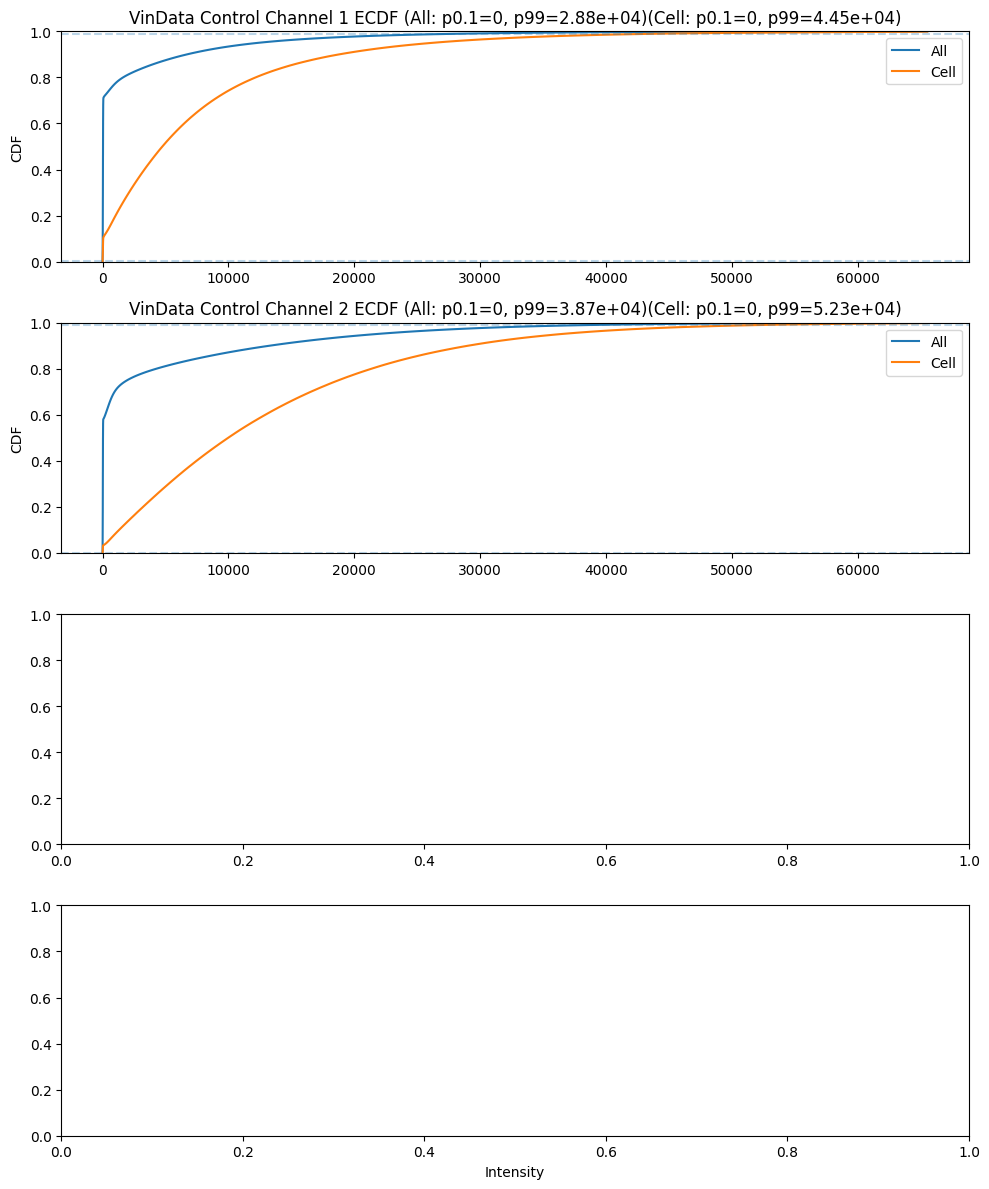

In [63]:
import matplotlib.pyplot as plt
import numpy as np

num_channels = 4

cell_idx  = all_pixel_data[:, 4] > 0
front_idx = all_pixel_data[:, 5] > 0

def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

fig, axes = plt.subplots(num_channels, 1, figsize=(10, 3*num_channels), sharex=False)

if num_channels == 1:
    axes = [axes]

for ch in [0,1]:
    ax = axes[ch]

    ch_all   = all_pixel_data[:, ch][::10]
    ch_cell  = all_pixel_data[cell_idx, ch][::10]
    
    # ---- percentiles from ch_all ----
    p_lo = np.percentile(ch_all, 0.1)
    p_hi = np.percentile(ch_all, 99)
    cell_p_lo = np.percentile(ch_cell, 0.1)
    cell_p_hi = np.percentile(ch_cell, 99)

    for data, label in [(ch_all, "All"), (ch_cell, "Cell")]:
        xs, ys = ecdf(data)
        ax.plot(xs, ys, label=label)

    # Optional guide lines
    for p in [0.1, 99]:
        ax.axhline(p / 100.0, linestyle="--", alpha=0.3)

    ax.set_title(
        f"VinData Control Channel {ch+1} ECDF "
        f"(All: p0.1={p_lo:.3g}, p99={p_hi:.3g})"
        f"(Cell: p0.1={cell_p_lo:.3g}, p99={cell_p_hi:.3g})"
    )
    ax.set_ylabel("CDF")
    ax.set_ylim(0, 1)
    ax.legend()

axes[-1].set_xlabel("Intensity")

plt.tight_layout()
plt.show()


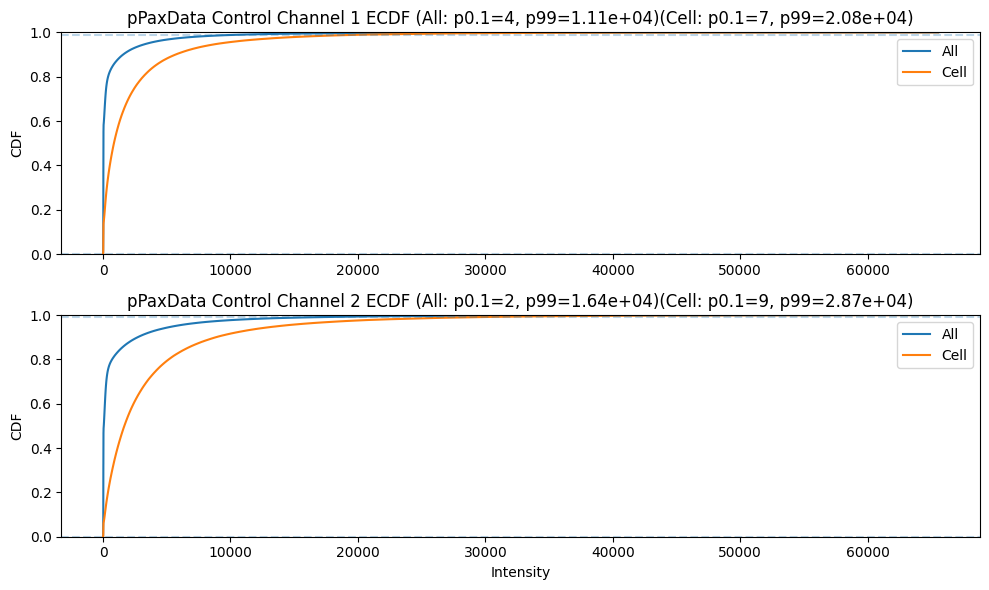

In [64]:
import matplotlib.pyplot as plt
import numpy as np

num_channels = 2

cell_idx  = pPax_all_pixel_data[:, 4] > 0
front_idx = pPax_all_pixel_data[:, 5] > 0

def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

fig, axes = plt.subplots(num_channels, 1, figsize=(10, 3*num_channels), sharex=False)

if num_channels == 1:
    axes = [axes]

for ch in [0,1]:
    ax = axes[ch]

    ch_all   = pPax_all_pixel_data[:, ch][::10]
    ch_cell  = pPax_all_pixel_data[cell_idx, ch][::10]
    
    # ---- percentiles from ch_all ----
    p_lo = np.percentile(ch_all, 0.1)
    p_hi = np.percentile(ch_all, 99)
    cell_p_lo = np.percentile(ch_cell, 0.1)
    cell_p_hi = np.percentile(ch_cell, 99)

    for data, label in [(ch_all, "All"), (ch_cell, "Cell")]:
        xs, ys = ecdf(data)
        ax.plot(xs, ys, label=label)

    # Optional guide lines
    for p in [0.1, 99]:
        ax.axhline(p / 100.0, linestyle="--", alpha=0.3)

    ax.set_title(
        f"pPaxData Control Channel {ch+1} ECDF "
        f"(All: p0.1={p_lo:.3g}, p99={p_hi:.3g})"
        f"(Cell: p0.1={cell_p_lo:.3g}, p99={cell_p_hi:.3g})"
    )
    ax.set_ylabel("CDF")
    ax.set_ylim(0, 1)
    ax.legend()

axes[-1].set_xlabel("Intensity")

plt.tight_layout()
plt.show()
